# Basic Lane Vehicle Counting

> Minimal workflow: load model -> mark lanes manually -> count vehicles in one image.

This notebook intentionally keeps only the core functionality and removes additional viewer/analysis code.

In [26]:
import os
import platform
import time

if platform.system() == "Linux":
    os.environ.setdefault("QT_QPA_FONTDIR", "/usr/share/fonts/truetype/dejavu")

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.cluster import DBSCAN
from sklearn.linear_model import LinearRegression

MODEL_WEIGHTS = "yolov8n.pt"
model = YOLO(MODEL_WEIGHTS)
model.to("cpu")

print("Model loaded:", MODEL_WEIGHTS)

Model loaded: yolov8n.pt


## Step 1 - Mark lane polygons manually

Use the auto guides only as visual hints. Final lane boundaries come from your manual clicks.

Keyboard controls:
- `z` undo point
- `r` reset current lane
- `b` previous lane
- `n` next lane (requires at least 3 points)
- `q` finish

In [27]:
def show_bgr(image, title, size=(12, 7)):
    plt.figure(figsize=size)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def detect_auto_lane_guides(img):
    h, w = img.shape[:2]

    hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)
    white_mask = cv2.inRange(hls, np.array([0, 190, 0]), np.array([180, 255, 255]))
    yellow_mask = cv2.inRange(hls, np.array([15, 40, 100]), np.array([35, 255, 255]))
    mask = cv2.bitwise_or(white_mask, yellow_mask)

    edges = cv2.Canny(mask, 50, 150)
    roi_poly = np.array([[(0, h), (w, h), (int(w * 0.8), int(h * 0.1)), (int(w * 0.4), int(h * 0.1))]], np.int32)
    roi_mask = np.zeros_like(edges)
    cv2.fillPoly(roi_mask, roi_poly, 255)
    masked_edges = cv2.bitwise_and(edges, roi_mask)

    lines = cv2.HoughLinesP(masked_edges, 1, np.pi / 180, 30, minLineLength=30, maxLineGap=200)

    features = []
    segments = []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if x1 == x2:
                continue
            m = (y2 - y1) / (x2 - x1)
            if abs(m) < 0.35:
                continue
            b = y1 - m * x1
            x_bottom = (h - b) / m
            theta = np.arctan(m)
            features.append([x_bottom / w, theta])
            segments.append((x1, y1, x2, y2))

    guides = []
    if features:
        labels = DBSCAN(eps=0.05, min_samples=1).fit_predict(features)
        for cluster_id in sorted(set(labels)):
            indices = np.where(labels == cluster_id)[0]
            pts = []
            for idx in indices:
                x1, y1, x2, y2 = segments[idx]
                pts.extend([(x1, y1), (x2, y2)])
            pts = np.array(pts)
            X = pts[:, 1].reshape(-1, 1)
            y = pts[:, 0]
            lr = LinearRegression().fit(X, y)
            y_range = np.array([h, int(h * 0.1)], dtype=np.int32)
            x_preds = np.asarray(lr.predict(y_range.reshape(-1, 1))).ravel()
            pt1 = (int(x_preds[0]), int(y_range[0]))
            pt2 = (int(x_preds[1]), int(y_range[1]))
            guides.append((pt1, pt2))

    return guides, roi_poly


def manual_select_lanes(ref_frame, auto_guides, num_lanes=3):
    lane_names = [f"Lane_{i + 1}" for i in range(num_lanes)]
    lane_points = {name: [] for name in lane_names}
    current_lane_idx = 0
    window_name = "Manual Lane Selection"

    def redraw():
        canvas = ref_frame.copy()

        for i, (pt1, pt2) in enumerate(auto_guides, start=1):
            cv2.line(canvas, pt1, pt2, (255, 255, 0), 2)
            cv2.putText(canvas, f"Guide {i}", pt1, cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2, cv2.LINE_AA)

        for i, name in enumerate(lane_names):
            pts = lane_points[name]
            if not pts:
                continue

            pts_np = np.array(pts, np.int32)
            color = (0, 255, 0) if i < current_lane_idx else (0, 255, 255)

            if len(pts) >= 2:
                cv2.polylines(canvas, [pts_np], isClosed=(len(pts) >= 3), color=color, thickness=2)

            for p in pts:
                cv2.circle(canvas, p, 4, (0, 0, 255), -1)

            label_x = min(max(pts[0][0] + 8, 10), ref_frame.shape[1] - 150)
            label_y = min(max(pts[0][1] - 8, 20), ref_frame.shape[0] - 10)
            cv2.putText(canvas, name, (label_x, label_y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)

        if current_lane_idx < len(lane_names):
            active = lane_names[current_lane_idx]
            status = f"Marking: {active} ({len(lane_points[active])} points)"
        else:
            status = "All lanes marked. Press q to finish."

        cv2.putText(canvas, status, (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(canvas, "z undo | r reset | b back | n next | q finish", (20, 58), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
        return canvas

    def on_mouse(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN and current_lane_idx < len(lane_names):
            lane_points[lane_names[current_lane_idx]].append((x, y))

    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.setMouseCallback(window_name, on_mouse)
    cv2.resizeWindow(window_name, ref_frame.shape[1], ref_frame.shape[0])

    while True:
        cv2.imshow(window_name, redraw())
        key = cv2.waitKey(20) & 0xFF

        if key == ord("z") and current_lane_idx < len(lane_names):
            if lane_points[lane_names[current_lane_idx]]:
                lane_points[lane_names[current_lane_idx]].pop()
        elif key == ord("r") and current_lane_idx < len(lane_names):
            lane_points[lane_names[current_lane_idx]] = []
        elif key == ord("b") and current_lane_idx > 0:
            current_lane_idx -= 1
        elif key == ord("n") and current_lane_idx < len(lane_names):
            lane_name = lane_names[current_lane_idx]
            if len(lane_points[lane_name]) >= 3:
                current_lane_idx += 1
            else:
                print(f"{lane_name}: add at least 3 points before next lane")
        elif key == ord("q"):
            break

    cv2.destroyAllWindows()
    return {name: np.array(points, np.int32) for name, points in lane_points.items()}

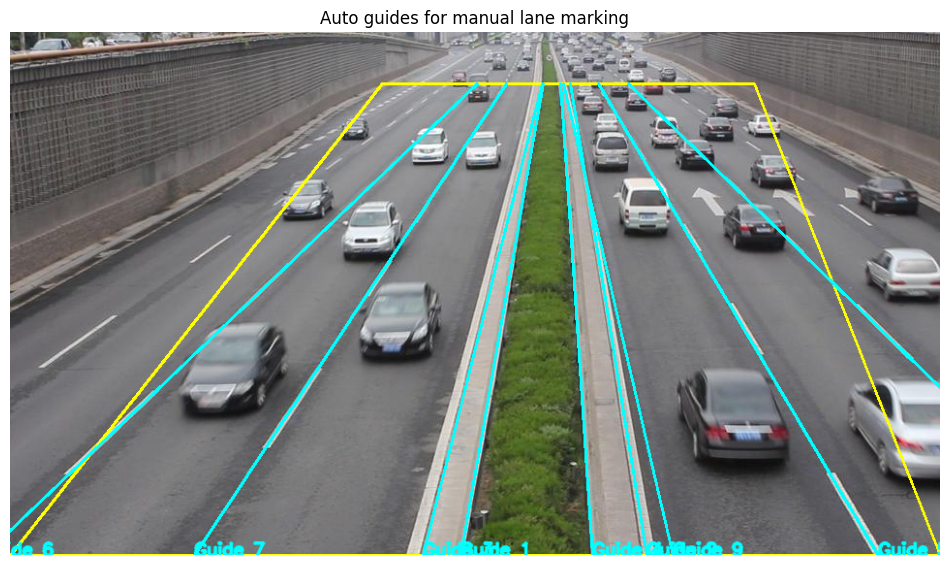

Lane polygons captured:
Lane_1: 4 points
Lane_2: 4 points
Lane_3: 4 points


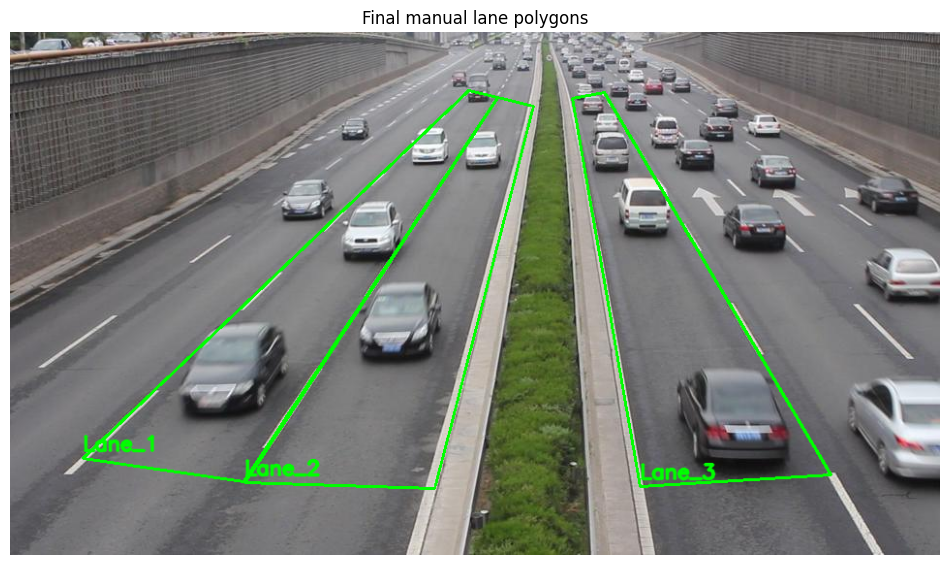

In [28]:
image_path = "dataset/best/img00001.jpg"
ref_frame = cv2.imread(image_path)
if ref_frame is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

auto_guides, roi_poly = detect_auto_lane_guides(ref_frame)

preview = ref_frame.copy()
cv2.polylines(preview, roi_poly, isClosed=True, color=(0, 255, 255), thickness=2)
for i, (pt1, pt2) in enumerate(auto_guides, start=1):
    cv2.line(preview, pt1, pt2, (255, 255, 0), 2)
    cv2.putText(preview, f"Guide {i}", pt1, cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2, cv2.LINE_AA)

show_bgr(preview, "Auto guides for manual lane marking")

lane_polygons = manual_select_lanes(ref_frame, auto_guides, num_lanes=3)
print("Lane polygons captured:")
for lane_name, poly in lane_polygons.items():
    print(f"{lane_name}: {len(poly)} points")

check = ref_frame.copy()
for lane_name, poly in lane_polygons.items():
    if len(poly) >= 2:
        cv2.polylines(check, [poly], isClosed=True, color=(0, 255, 0), thickness=2)
    if len(poly) >= 1:
        x, y = poly[0]
        cv2.putText(check, lane_name, (int(x), int(y) - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)

show_bgr(check, "Final manual lane polygons")

## Step 2 - Count vehicles in one image

This step runs YOLO once per lane polygon and counts vehicles by anchor-point-in-polygon logic.

Vehicle counts: {'Lane_1': 5, 'Lane_2': 2, 'Lane_3': 6}
Processing time: 343.8 ms (2.91 FPS)


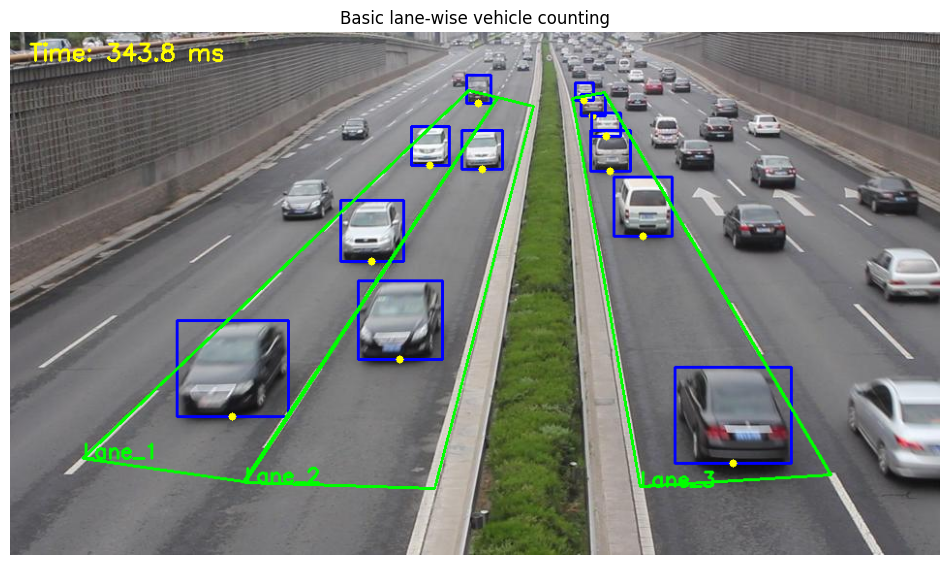

In [29]:
def draw_lanes(frame, lane_polygons):
    for name, poly in lane_polygons.items():
        if len(poly) >= 2:
            cv2.polylines(frame, [poly], isClosed=True, color=(0, 255, 0), thickness=2)
        if len(poly) >= 1:
            cv2.putText(frame, name, tuple(poly[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    return frame


def get_vehicle_anchor(x1, y1, x2, y2):
    return (x1 + x2) // 2, y2


def detect_vehicles_in_polygon(frame, poly, model, conf=0.25, imgsz=640, vehicle_classes={2, 3, 5, 7}, padding=20):
    x, y, w, h = cv2.boundingRect(poly)
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(frame.shape[1], x + w + padding)
    y2 = min(frame.shape[0], y + h + padding)
    roi = frame[y1:y2, x1:x2].copy()
    if roi.size == 0 or roi.shape[0] < 16 or roi.shape[1] < 16:
        return []

    results = model(roi, conf=conf, imgsz=imgsz, verbose=False, device="cpu")
    detections = []
    for result in results:
        for box in result.boxes:
            cls = int(box.cls[0])
            if cls not in vehicle_classes:
                continue

            bx1, by1, bx2, by2 = map(int, box.xyxy[0])
            gx1, gy1 = bx1 + x1, by1 + y1
            gx2, gy2 = bx2 + x1, by2 + y1
            cx, cy = get_vehicle_anchor(gx1, gy1, gx2, gy2)

            if cv2.pointPolygonTest(poly, (cx, cy), False) >= 0:
                detections.append({
                    "bbox": (gx1, gy1, gx2, gy2),
                    "anchor": (cx, cy),
                    "cls": cls,
                    "conf": float(box.conf[0]),
                })
    return detections


if "lane_polygons" not in globals() or not lane_polygons:
    raise ValueError("lane_polygons is empty. Run Step 1 first.")

frame = cv2.imread("dataset/best/img00001.jpg")
if frame is None:
    raise FileNotFoundError("dataset/best/img00001.jpg not found")

start_t = time.perf_counter()
counts = {name: 0 for name in lane_polygons}
for lane_name, poly in lane_polygons.items():
    if len(poly) < 3:
        continue
    detections = detect_vehicles_in_polygon(frame, poly, model, conf=0.25)
    counts[lane_name] += len(detections)
    for det in detections:
        x1, y1, x2, y2 = det["bbox"]
        cx, cy = det["anchor"]
        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.circle(frame, (cx, cy), 4, (0, 255, 255), -1)
elapsed_ms = (time.perf_counter() - start_t) * 1000.0

frame = draw_lanes(frame, lane_polygons)
cv2.putText(frame, f"Time: {elapsed_ms:.1f} ms", (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
print("Vehicle counts:", counts)
print(f"Processing time: {elapsed_ms:.1f} ms ({1000.0 / max(elapsed_ms, 1e-6):.2f} FPS)")
show_bgr(frame, "Basic lane-wise vehicle counting")

## Step 3 - Test other images in dataset + timing comparison

Use this to validate counts and measure performance on many images with the same lane polygons.

Controls: `a` previous, `d` next, `q` or `Esc` to exit.

For laptop vs Luckfox comparison, keep these identical on both devices:
- same model weights
- same image set
- same confidence threshold
- same image size (`imgsz`)

In [30]:
from pathlib import Path

if "lane_polygons" not in globals() or not lane_polygons:
    raise ValueError("lane_polygons is empty. Run Step 1 first.")

dataset_dir = Path("dataset/best")
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
image_paths = sorted([p for p in dataset_dir.rglob("*") if p.suffix.lower() in valid_exts])

if not image_paths:
    raise FileNotFoundError(f"No images found in {dataset_dir.resolve()}")

window_name = "Dataset Test (a:prev, d:next, q/esc:exit)"
index = 0
needs_redraw = True
timing_history_ms = []

cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

while True:
    if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:
        break

    if needs_redraw:
        img_path = image_paths[index]
        frame = cv2.imread(str(img_path))

        if frame is None:
            display = np.full((220, 1000, 3), 255, dtype=np.uint8)
            cv2.putText(display, f"Failed to load: {img_path}", (20, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
        else:
            t0 = time.perf_counter()
            display = frame.copy()
            counts = {name: 0 for name in lane_polygons}

            for lane_name, poly in lane_polygons.items():
                if len(poly) < 3:
                    continue
                detections = detect_vehicles_in_polygon(display, poly, model, conf=0.25, imgsz=640)
                counts[lane_name] += len(detections)

                for det in detections:
                    x1, y1, x2, y2 = det["bbox"]
                    cx, cy = det["anchor"]
                    cv2.rectangle(display, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.circle(display, (cx, cy), 4, (0, 255, 255), -1)

            elapsed_ms = (time.perf_counter() - t0) * 1000.0
            timing_history_ms.append(elapsed_ms)

            display = draw_lanes(display, lane_polygons)

            y0 = 60
            for lane_name in lane_polygons.keys():
                cv2.putText(display, f"{lane_name}: {counts[lane_name]}", (20, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
                y0 += 28

            cv2.putText(display, f"{index + 1}/{len(image_paths)} | {img_path.name}", (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            cv2.putText(display, f"Current: {elapsed_ms:.1f} ms", (20, y0 + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

            stable = timing_history_ms[1:] if len(timing_history_ms) > 1 else timing_history_ms
            avg_ms = float(np.mean(stable))
            cv2.putText(display, f"Avg: {avg_ms:.1f} ms ({1000.0 / max(avg_ms, 1e-6):.2f} FPS)", (20, y0 + 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

        cv2.imshow(window_name, display)
        needs_redraw = False

    key = cv2.waitKey(30) & 0xFF
    if key in [ord("d"), 83]:
        index = (index + 1) % len(image_paths)
        needs_redraw = True
    elif key in [ord("a"), 81]:
        index = (index - 1) % len(image_paths)
        needs_redraw = True
    elif key in [ord("q"), 27]:
        break

cv2.destroyWindow(window_name)

if timing_history_ms:
    stable = timing_history_ms[1:] if len(timing_history_ms) > 1 else timing_history_ms
    avg_ms = float(np.mean(stable))
    p95_ms = float(np.percentile(stable, 95))
    min_ms = float(np.min(stable))
    max_ms = float(np.max(stable))
    print("\nTiming summary (first frame excluded if possible):")
    print(f"Frames measured: {len(stable)}")
    print(f"Avg: {avg_ms:.2f} ms | P95: {p95_ms:.2f} ms | Min: {min_ms:.2f} ms | Max: {max_ms:.2f} ms")
    print(f"Approx FPS: {1000.0 / max(avg_ms, 1e-6):.2f}")


Timing summary (first frame excluded if possible):
Frames measured: 149
Avg: 155.53 ms | P95: 192.09 ms | Min: 137.91 ms | Max: 198.05 ms
Approx FPS: 6.43
